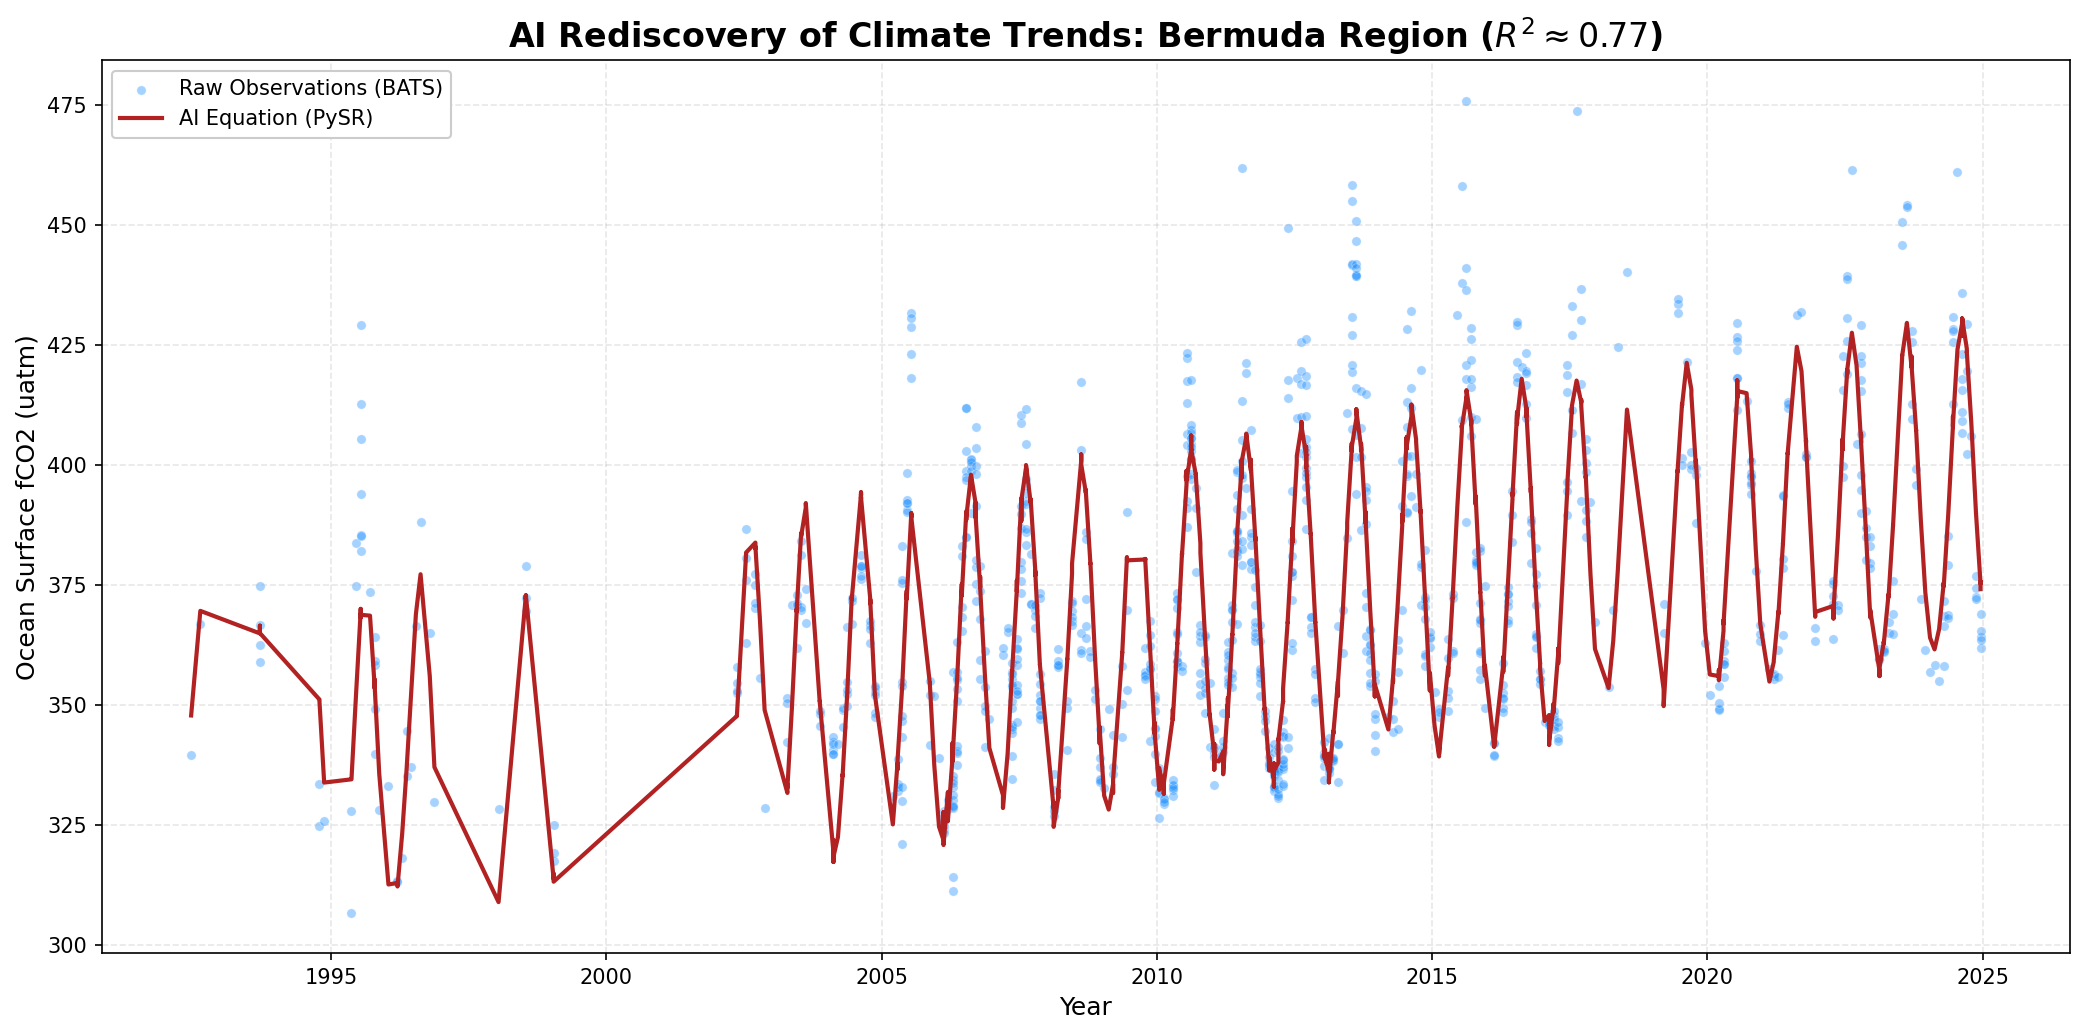

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Config ---
DATA_PATH = Path("../data/03_processed/training_set.parquet")
LAT_MIN, LAT_MAX = 25, 35
LON_MIN, LON_MAX = -70, -60

# --- Load Data (BATS Region) ---
df = pd.read_parquet(DATA_PATH)
df = df[
    (df["lat"] >= LAT_MIN) & (df["lat"] <= LAT_MAX) &
    (df["lon"] >= LON_MIN) & (df["lon"] <= LON_MAX)
].copy()

# Feature Engineering
df['Season_Sin'] = np.sin(2 * np.pi * (df['Year'] % 1))
df['Season_Cos'] = np.cos(2 * np.pi * (df['Year'] % 1))

# --- The Discovered Equation ---
# From your specific PySR output:
# -(SST*(Season_Cos + Season_Sin) + Year*(-1.8897)) - 3435.7
def predict_fco2(row):
    SST = row['SST']
    Year = row['Year']
    Sin = row['Season_Sin']
    Cos = row['Season_Cos']
    
    # Calculate Prediction
    return -(SST * (Cos + Sin) + Year * (-1.8897)) - 3435.74

df['AI_Prediction'] = df.apply(predict_fco2, axis=1)

# --- Visualization ---
plt.figure(figsize=(14, 7), dpi=150)

# 1. Plot Raw Data (Blue dots)
# We sample 1000 points so the plot isn't too crowded
plot_df = df.sample(n=1000, random_state=42).sort_values("Year")

sns.scatterplot(
    data=plot_df, x="Year", y="fCO2", 
    color="dodgerblue", alpha=0.4, s=20, label="Raw Observations (BATS)"
)

# 2. Plot AI Prediction (Red Line)
plt.plot(plot_df["Year"], plot_df["AI_Prediction"], 
         color="firebrick", linewidth=2, label="AI Equation (PySR)")

# Styling
plt.title("AI Rediscovery of Climate Trends: Bermuda Region ($R^2 \\approx 0.77$)", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Ocean Surface fCO2 (uatm)", fontsize=12)
plt.legend(frameon=True, fancybox=True, framealpha=1, loc="upper left")
plt.grid(True, alpha=0.3, linestyle="--")

# Save and Show
plt.tight_layout()
plt.savefig("results_plot.png") # Saves image to folder
plt.show()